<div style="display:block;width:100%;margin:auto;" direction=rtl align=center><br><br>
    <div  style="width:100%;margin:100;display:block;background-color:#fff0;"  display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">             <tr>
                <td  style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>Armin Ghasemi</b><br><br>810100198</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> ML </b><br><br>HW2_Q5</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>  </b><br><br></i></font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
           </tr>
        </table>
    </div>
</div>


# 📊 Gaussian Discriminant Analysis (GDA) Simulation
### Manual Implementation of Bayes Classifier & Decision Boundary

> **Course:** Machine Learning | University of Tehran
> **Assignment:** Homework 2 - Question 5
> **Topic:** Generative Learning Algorithms (From Scratch)

---

## 📝 Problem Statement
The goal is to simulate a **Binary Classification** problem where data is generated from two distinct **Gaussian Distributions** ($N(\mu, \sigma)$). Instead of using pre-built classifiers, we implement the **Discriminant Functions** and **Decision Boundaries** mathematically using only NumPy.

**Key Objectives:**
1.  **Mathematical Implementation:** Define the discriminant function $g(x)$ for normal distributions.
2.  **Decision Boundary:** Calculate and visualize the optimal boundary for minimum error.
3.  **Prior Probability Analysis:** Analyze how changing priors ($\pi_1, \pi_2$) shifts the decision boundary.
4.  **Data Simulation:** Generate synthetic samples for two classes based on parameters.
5.  **Evaluation from Scratch:** Manually calculate **Confusion Matrix**, **F1-Score**, and plotting the **ROC Curve** (and AUROC) by sweeping the threshold $\tau$.

---

### Imports

In [260]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from numpy import trapezoid

### a,b)Discriminant Function:

In [261]:
def discriminant_function(x, mu, sigma, prior):
    term1 = -np.log(sigma)  
    term2 = -0.5 * ((x-mu)/sigma)**2 
    term3 = np.log(prior)  
    return term1 + term2 + term3

In [262]:

mu1 = 2
sigma1 = 1
pi1 = 0.5

mu2 = 4
sigma2 = 1
pi2 = 0.5

x = np.linspace(-1, 6, 100)
g1 = discriminant_function(x, mu1, sigma1, pi1)
g2 = discriminant_function(x, mu2, sigma2, pi2)
g = g1 - g2

decision_boundary = x[np.argmin(np.abs(g))]
decision_boundary

np.float64(3.0303030303030303)

### c)Changing the prior:

In [263]:
mu1 = 2
sigma1 = 1
pi1 = 0.1

mu2 = 4
sigma2 = 1
pi2 = 0.9

x = np.linspace(-1, 6, 100)
g1 = discriminant_function(x, mu1, sigma1, pi1)
g2 = discriminant_function(x, mu2, sigma2, pi2)
g = g1 - g2

decision_boundary = x[np.argmin(np.abs(g))]
decision_boundary

np.float64(1.8989898989898988)

In [264]:
mu1 = 2
sigma1 = 1
pi1 = 0.9

mu2 = 4
sigma2 = 1
pi2 = 0.1

x = np.linspace(-1, 6, 100)
g1 = discriminant_function(x, mu1, sigma1, pi1)
g2 = discriminant_function(x, mu2, sigma2, pi2)
g = g1 - g2

decision_boundary = x[np.argmin(np.abs(g))]
decision_boundary

np.float64(4.090909090909091)

In [265]:
mu1 = 2
sigma1 = 1
pi1 = 0.5

mu2 = 4
sigma2 = 1
pi2 = 0.5

x = np.linspace(-1, 6, 100)
g1 = discriminant_function(x, mu1, sigma1, pi1)
g2 = discriminant_function(x, mu2, sigma2, pi2)
g = g1 - g2

decision_boundary = x[np.argmin(np.abs(g))]
decision_boundary

np.float64(3.0303030303030303)

### d)Plot Samples:

##### generate samples

In [266]:
samples_C1 = np.random.normal(mu1, sigma1, 100)
samples_C2 = np.random.normal(mu2, sigma2, 100)


##### scatter plot

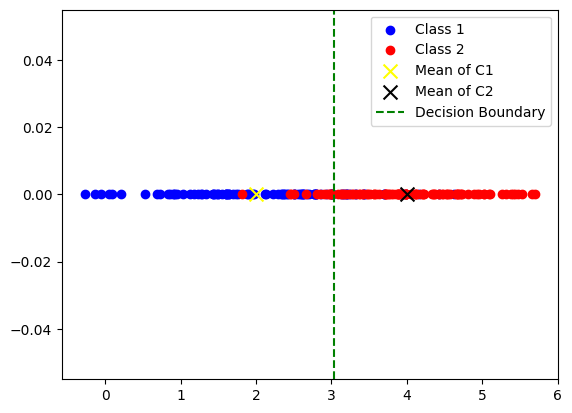

In [267]:
plt.scatter(samples_C1, [0]*len(samples_C1), color='blue', label='Class 1')
plt.scatter(samples_C2, [0]*len(samples_C2), color='red', label='Class 2')

plt.scatter(mu1, 0, color='yellow', marker='x', s=100, label="Mean of C1")
plt.scatter(mu2, 0, color='black', marker='x', s=100, label="Mean of C2")


plt.axvline(x=decision_boundary, color='green', linestyle='--', label='Decision Boundary')

plt.legend()
plt.show()

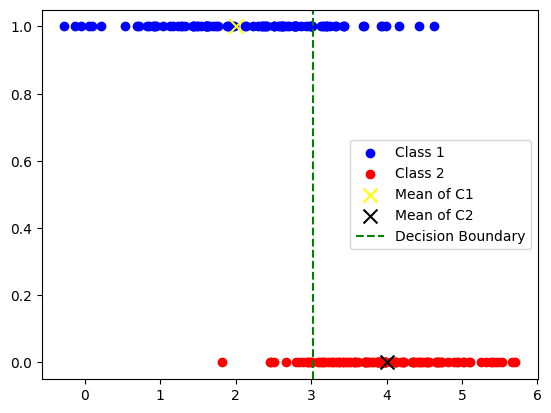

In [268]:
plt.scatter(samples_C1, [1]*len(samples_C1), color='blue', label='Class 1')
plt.scatter(samples_C2, [0]*len(samples_C2), color='red', label='Class 2')

plt.scatter(mu1, 1, color='yellow', marker='x', s=100, label="Mean of C1")
plt.scatter(mu2, 0, color='black', marker='x', s=100, label="Mean of C2")


plt.axvline(x=decision_boundary, color='green', linestyle='--', label='Decision Boundary')

plt.legend()
plt.show()

##### Histogram plot

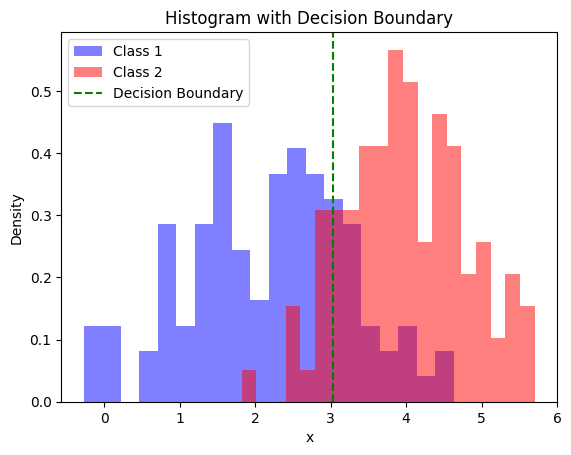

In [269]:
plt.hist(samples_C1, bins=20, color='blue', alpha=0.5, label='Class 1', density=True)
plt.hist(samples_C2, bins=20, color='red', alpha=0.5, label='Class 2', density=True)

plt.axvline(x=decision_boundary, color='green', linestyle='--', label='Decision Boundary')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Histogram with Decision Boundary')
plt.legend()
plt.show()

##### PDF plot

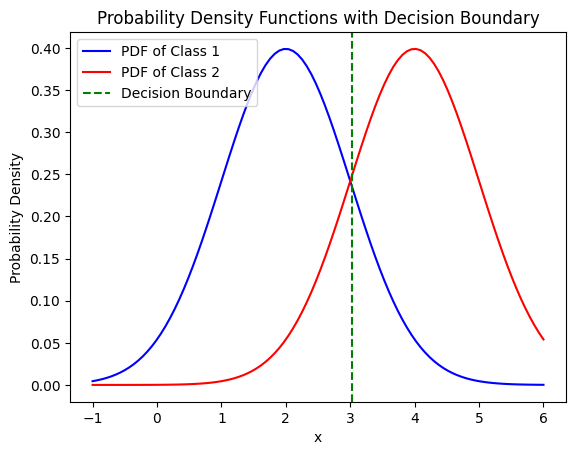

In [270]:
from scipy.stats import norm

x = np.linspace(-1, 6, 100)
pdf_C1 = norm.pdf(x, mu1, sigma1)
pdf_C2 = norm.pdf(x, mu2, sigma2)

plt.plot(x, pdf_C1, color='blue', label='PDF of Class 1')
plt.plot(x, pdf_C2, color='red', label='PDF of Class 2')

plt.axvline(x=decision_boundary, color='green', linestyle='--', label='Decision Boundary')

plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title('Probability Density Functions with Decision Boundary')
plt.legend()
plt.show()

### e)confusion matrix, accuracy, precision, recall and F1:

In [271]:
samples_C1 = np.random.normal(mu1, sigma1, 100)
samples_C2 = np.random.normal(mu2, sigma2, 100)

labels_C1 = np.ones(len(samples_C1)) 
labels_C2 = np.zeros(len(samples_C2))  

x = np.concatenate([samples_C1, samples_C2])
labels = np.concatenate([labels_C1, labels_C2])

g1 = discriminant_function(x, mu1, sigma1, pi1)
g2 = discriminant_function(x, mu2, sigma2, pi2)
g = g1 - g2

predicted_labels = (g >= 0).astype(int)

TP = np.sum((predicted_labels == 1) & (labels == 1))
FP = np.sum((predicted_labels == 1) & (labels == 0))
TN = np.sum((predicted_labels == 0) & (labels == 0))
FN = np.sum((predicted_labels == 0) & (labels == 1))

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("Confusion Matrix:")
print(f"{TP}  {FP}")
print(f"{TN}  {FN}")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1_score:.2f}")

Confusion Matrix:
89  15
85  11
Accuracy: 0.87
Precision: 0.86
Recall: 0.89
F1-Score: 0.87


### f)ROC:

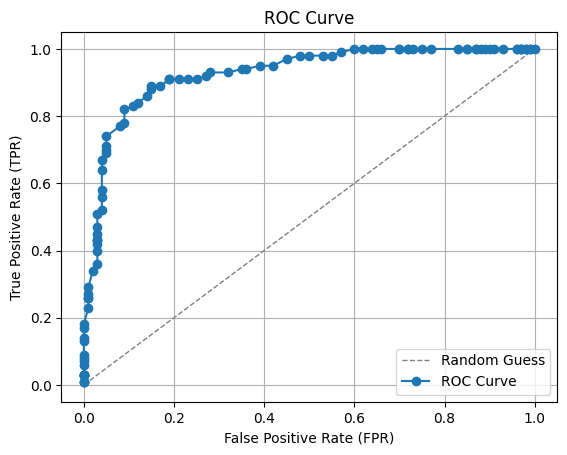

AUROC (Trapzoidal Method): 0.426150


In [272]:
thresholds = np.linspace(min(g), max(g), 100)

tpr_list = []
fpr_list = []

for tau in thresholds:

    predictions = (g >= tau).astype(int)

    TP = np.sum((predictions == 1) & (labels == 1))
    FP = np.sum((predictions == 1) & (labels == 0))
    FN = np.sum((predictions == 0) & (labels == 1))
    TN = np.sum((predictions == 0) & (labels == 0))
    
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
    
    tpr_list.append(TPR)
    fpr_list.append(FPR)


plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label="Random Guess")
plt.plot(fpr_list, tpr_list, marker='o', label='ROC Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()


sorted_indices = np.argsort(fpr_list)
fpr_list = np.array(fpr_list)[sorted_indices]
tpr_list = np.array(tpr_list)[sorted_indices]
auroc = trapezoid(tpr_list, fpr_list)
print(f"AUROC (Trapzoidal Method): {(auroc-0.5 ):.6f}")

### g):

In [273]:
mu1 = 2
sigma1 = 1
pi1 = 0.9

mu2 = 4
sigma2 = 1
pi2 = 0.1

x = np.linspace(-1, 6, 100)
g1 = discriminant_function(x, mu1, sigma1, pi1)
g2 = discriminant_function(x, mu2, sigma2, pi2)
g = g1 - g2

decision_boundary = x[np.argmin(np.abs(g))]
decision_boundary

np.float64(4.090909090909091)

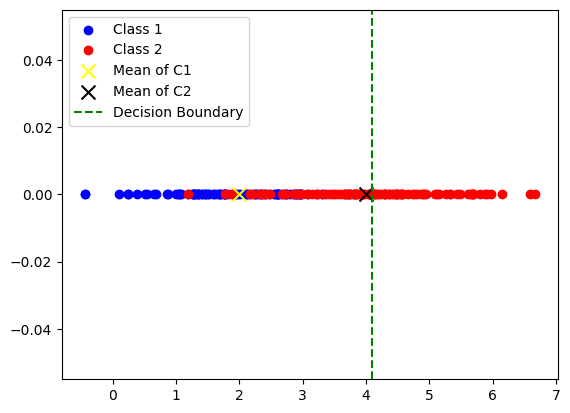

In [274]:
samples_C1 = np.random.normal(mu1, sigma1, 100)
samples_C2 = np.random.normal(mu2, sigma2, 100)
plt.scatter(samples_C1, [0]*len(samples_C1), color='blue', label='Class 1')
plt.scatter(samples_C2, [0]*len(samples_C2), color='red', label='Class 2')

plt.scatter(mu1, 0, color='yellow', marker='x', s=100, label="Mean of C1")
plt.scatter(mu2, 0, color='black', marker='x', s=100, label="Mean of C2")


plt.axvline(x=decision_boundary, color='green', linestyle='--', label='Decision Boundary')

plt.legend()
plt.show()

In [275]:
samples_C1 = np.random.normal(mu1, sigma1, 100)
samples_C2 = np.random.normal(mu2, sigma2, 100)

labels_C1 = np.ones(len(samples_C1)) 
labels_C2 = np.zeros(len(samples_C2))  

x = np.concatenate([samples_C1, samples_C2])
labels = np.concatenate([labels_C1, labels_C2])

g1 = discriminant_function(x, mu1, sigma1, pi1)
g2 = discriminant_function(x, mu2, sigma2, pi2)
g = g1 - g2

predicted_labels = (g >= 0).astype(int)

TP = np.sum((predicted_labels == 1) & (labels == 1))
FP = np.sum((predicted_labels == 1) & (labels == 0))
TN = np.sum((predicted_labels == 0) & (labels == 0))
FN = np.sum((predicted_labels == 0) & (labels == 1))

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("Confusion Matrix:")
print(f"{TP}  {FP}")
print(f"{TN}  {FN}")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1_score:.2f}")

Confusion Matrix:
97  50
50  3
Accuracy: 0.73
Precision: 0.66
Recall: 0.97
F1-Score: 0.79


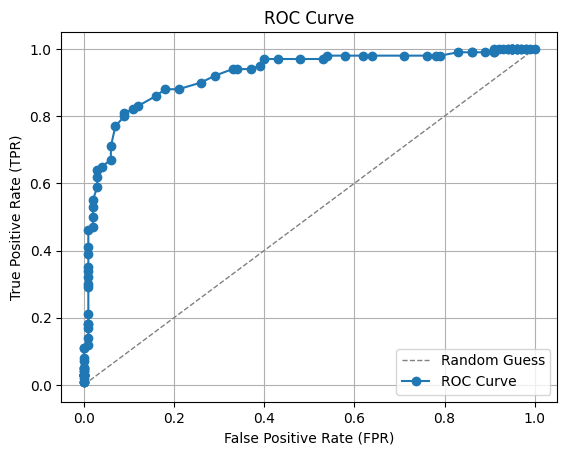

AUROC (Trapzoidal Method): 0.422350


In [276]:
thresholds = np.linspace(min(g), max(g), 100)

tpr_list = []
fpr_list = []

for tau in thresholds:

    predictions = (g >= tau).astype(int)

    TP = np.sum((predictions == 1) & (labels == 1))
    FP = np.sum((predictions == 1) & (labels == 0))
    FN = np.sum((predictions == 0) & (labels == 1))
    TN = np.sum((predictions == 0) & (labels == 0))
    
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
    
    tpr_list.append(TPR)
    fpr_list.append(FPR)


plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label="Random Guess")
plt.plot(fpr_list, tpr_list, marker='o', label='ROC Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()


sorted_indices = np.argsort(fpr_list)
fpr_list = np.array(fpr_list)[sorted_indices]
tpr_list = np.array(tpr_list)[sorted_indices]
auroc = trapezoid(tpr_list, fpr_list)
print(f"AUROC (Trapzoidal Method): {(auroc-0.5 ):.6f}")